# Data Analysis - Superstore

This notebook calculates core business performance metrics based on the previously prepared Superstore dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("../data/dim_customer.csv")
products = pd.read_csv("../data/dim_product.csv")
sales = pd.read_csv("../data/fact_sales.csv")

In [3]:
sales["order_date_day"] = pd.to_datetime(sales["order_date_day"])
sales["ship_date_day"] = pd.to_datetime(sales["ship_date_day"])

In [4]:
sales_customers = pd.merge(sales, customers, on='customer_id', how='left')
sales_final = pd.merge(sales_customers, products, on='product_id', how='left')

In [5]:
sales_final.shape

(9994, 21)

### Reusable Functions

In [6]:
def grouped_calc (data_frame, grouping_column, value_column, aggregation="sum", sort_by_value=True):
    """
    Groups selected data frame by a specified column and calculates chosen aggregation (with sum being the default aggregation).
    Sorts values in a descending order only when sort_by_value=True.
    """
    result = data_frame.groupby(grouping_column)[value_column].agg(aggregation)
    if sort_by_value:
        result = result.sort_values(ascending=False)
    
    return result

In [7]:
def column_summary (data_frame, column):
    """
    Builds a KPI table with aggregations based on a chosen column (e.g. customer_id, product_id).
    Returns a dataframe with sales, profit, number of orders, profit margin - sorted descending by sales)
    """
    summary = data_frame.groupby(column).agg(
        total_sales = ("sales", "sum"),
        total_profit = ("profit", "sum"),
        number_of_orders = ("order_id", "nunique"))
    
    summary["profit_margin"] = (summary["total_profit"] / summary["total_sales"]) * 100
    summary = summary.round({"total_sales":2, "total_profit":2, "profit_margin":2})
    summary = summary.sort_values("total_sales", ascending = False)
    
    return summary

### Performance Analysis (KPI)

The below section calculates the core performance metrics for the previously prepared dataset, including:
- total profit
- total sales
- profit margin
- number of orders
- number of customers
- average order value

In [8]:
total_profit = sales_final["profit"].sum().round(2)
total_sales = sales_final["sales"].sum().round(2)
profit_margin = round((total_profit / total_sales)*100,2)
number_of_orders = sales_final["order_id"].nunique()
number_of_customers = sales_final["customer_id"].nunique()
avg_order_value = round((total_sales / number_of_orders),2)

print(
f"""
KPI Interpretation:
- The business generated approximately {round((total_sales/1000000),2)}M in total sales.
- Total profit amounts to approximately {round(total_profit/1000)}K, with profit margin at almost {round(profit_margin,1)}%, indicating overall profitability.
- The dataset contains {number_of_orders} unique orders across {number_of_customers} customers.
- The average order value is approximately {avg_order_value}.
""")


KPI Interpretation:
- The business generated approximately 2.3M in total sales.
- Total profit amounts to approximately 286K, with profit margin at almost 12.5%, indicating overall profitability.
- The dataset contains 5009 unique orders across 793 customers.
- The average order value is approximately 458.61.



### Sales, Profit and Profit Margin by Category

In [9]:
sales_by_category = grouped_calc(sales_final, 'category', 'sales')
profit_by_category = grouped_calc(sales_final, 'category', 'profit')
profit_margin_by_category = round(((profit_by_category / sales_by_category) * 100),2)
profit_margin_by_category = profit_margin_by_category.sort_values(ascending=False)

print("Sales by Category:")
print(sales_by_category)

print("\nProfit by Category:")
print(profit_by_category)

print("\nProfit Margin by Category:")
print(profit_margin_by_category)

Sales by Category:
category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

Profit by Category:
category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

Profit Margin by Category:
category
Technology         17.40
Office Supplies    17.04
Furniture           2.49
dtype: float64


#### Interpretation
- Technology generates the highest sales and profit, making it the strongest performing category.
- Office Supplies performs well in both revenue and margin.
- Furniture shows significantly lower profitability (2.49% margin), which may indicate pricing, discounting, or cost inefficiencies.

### Profit by Sub-category

In [10]:
profit_by_subcategory = grouped_calc(sales_final, 'sub_category', 'profit')

print("Top 5 Most Profitable Sub-Categories:")
print(profit_by_subcategory.head(5))

print("\nBottom 5 Least Profitable Sub-Categories:")
print(profit_by_subcategory.tail(5))

Top 5 Most Profitable Sub-Categories:
sub_category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: profit, dtype: float64

Bottom 5 Least Profitable Sub-Categories:
sub_category
Machines      3384.7569
Fasteners      949.5182
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: profit, dtype: float64


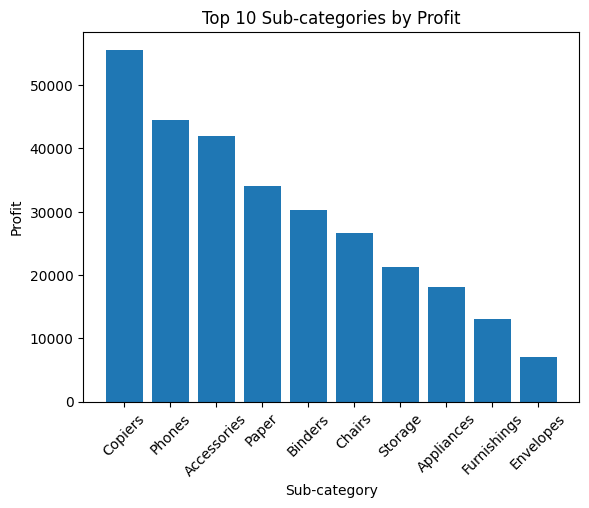

In [11]:
top_10_profit = profit_by_subcategory.head(10)

subcategory = top_10_profit.index
profit_value = top_10_profit.values

plt.bar(subcategory, profit_value)
plt.title("Top 10 Sub-categories by Profit")
plt.xlabel("Sub-category")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.show()

#### Interpretation

- Copiers and Phones are the most profitable sub-categories.
- Tables show a significant negative profit (–17.7K), indicating a major issue.
- Bookcases and Supplies also generate losses.
- The losses in Furniture-related sub-categories explain the weak overall Furniture margin observed earlier.

### Sales, Profit and Profit Margin by Year

In [12]:
sales_final['order_date_year'] = sales_final['order_date_day'].dt.year

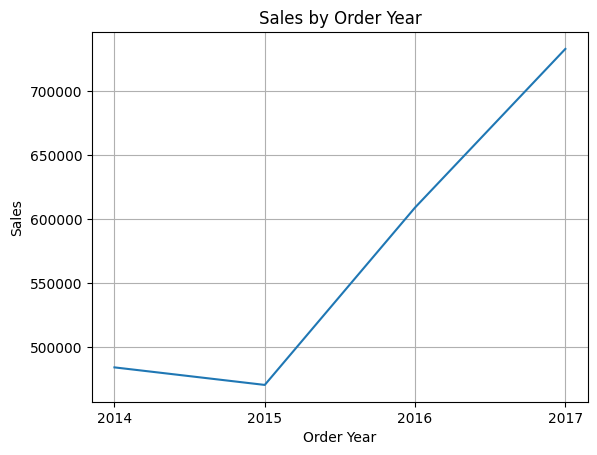

In [13]:
sales_by_year = grouped_calc(sales_final, 'order_date_year', 'sales')
sales_by_year = sales_by_year.sort_index()

year = sales_by_year.index.astype(int)
sales_value = sales_by_year.values

plt.plot(year, sales_value)
plt.xticks(year)
plt.grid(True)
plt.xlabel("Order Year")
plt.ylabel("Sales")
plt.title("Sales by Order Year")

plt.show()

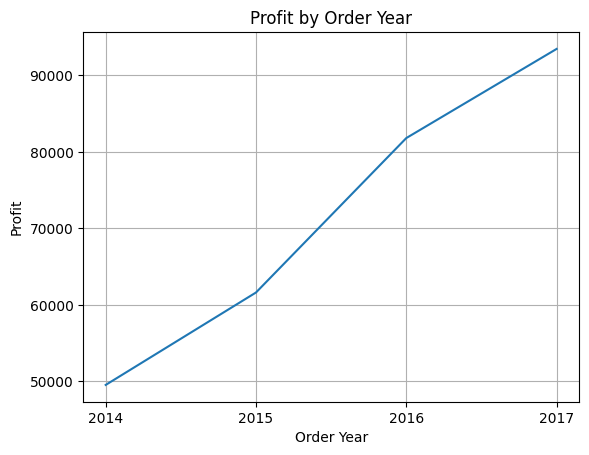

In [14]:
profit_by_year = grouped_calc(sales_final, 'order_date_year', 'profit')
profit_by_year = profit_by_year.sort_index()

year = profit_by_year.index.astype(int)
profit_value = profit_by_year.values

plt.plot(year, profit_value)
plt.xticks(year)
plt.grid(True)
plt.xlabel("Order Year")
plt.ylabel("Profit")
plt.title("Profit by Order Year")

plt.show()

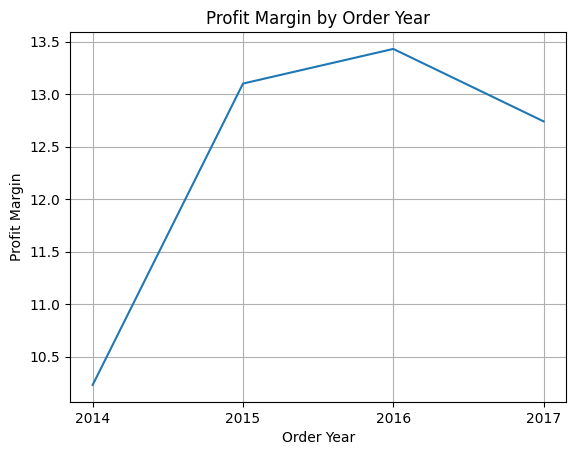

In [15]:
profit_margin_by_year = round((profit_by_year / sales_by_year) * 100, 2)

year = profit_margin_by_year.index.astype(int)
profit_margin_value = profit_margin_by_year.values

plt.plot(year, profit_margin_value)
plt.xticks(year)
plt.grid(True)
plt.xlabel("Order Year")
plt.ylabel("Profit Margin")
plt.title("Profit Margin by Order Year")

plt.show()

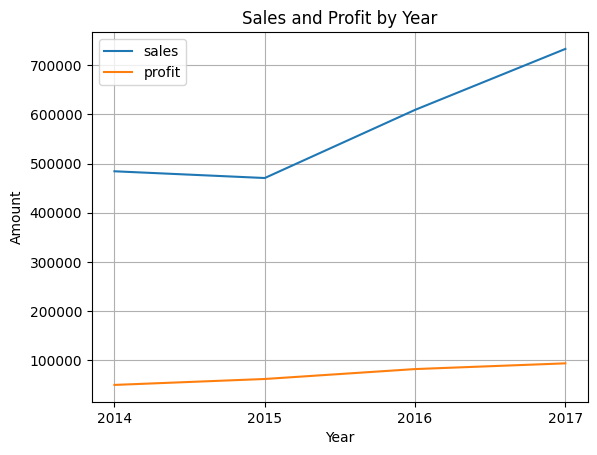

In [16]:
sales_value = sales_by_year.values
profit_value = profit_by_year.values

plt.plot(year, sales_value, label = 'sales')
plt.plot(year, profit_value, label = 'profit')
plt.xticks(year)
plt.ylabel('Amount')
plt.xlabel('Year')
plt.title('Sales and Profit by Year')
plt.grid(True)

plt.legend()
plt.show()

#### Interpretation

- Profit was continuously increasing from 2014 to 2017.
- Profit margin improved significantly from around 10.2% in 2014 to over 13% in 2015-2016.
- Despite continuous sales and profit growth in 2016, the profit margin slightly declined, suggesting possible pricing or cost issues.
- Overall, the analysis shows both revenue growth and improvement in efficiency over time.

### KPI Summary by Product ID

In [17]:
column_summary(sales_final, "product_id")

,total_sales,total_profit,number_of_orders,profit_margin
product_id,,,,
TEC-CO-10004722,61599.82,25199.93,5,40.91
OFF-BI-10003527,27453.38,7753.04,10,28.24
TEC-MA-10002412,22638.48,-1811.08,1,-8.00
FUR-CH-10002024,21870.58,0.00,8,0.00
OFF-BI-10001359,19823.48,2233.51,11,11.27
...,...,...,...,...
OFF-AR-10003986,7.70,3.16,1,41.00
OFF-EN-10001535,7.07,2.39,1,33.75
OFF-PA-10000048,6.48,3.11,1,48.00


### KPI Summary by Customer ID

In [18]:
customer_summary = column_summary(sales_final, "customer_id")

metrics = ["total_sales", "total_profit", "number_of_orders", "profit_margin"]

for m in metrics:
    top5 = customer_summary.sort_values(m, ascending = False).head(5)
    bottom5 = customer_summary.sort_values(m, ascending = True).head(5)
    print(f"\n\nCustomer ranking by {m}:")

    print("Top 5:")
    print(top5[[m]])

    print("\nBottom 5:")
    print(bottom5[[m]])
    



Customer ranking by total_sales:
Top 5:
             total_sales
customer_id             
SM-20320        25043.05
TC-20980        19052.22
RB-19360        15117.34
TA-21385        14595.62
AB-10105        14473.57

Bottom 5:
             total_sales
customer_id             
TS-21085            4.83
LD-16855            5.30
CJ-11875           16.52
MG-18205           16.74
RS-19870           22.33


Customer ranking by total_profit:
Top 5:
             total_profit
customer_id              
TC-20980          8981.32
RB-19360          6976.10
SC-20095          5757.41
HL-15040          5622.43
AB-10105          5444.81

Bottom 5:
             total_profit
customer_id              
CS-12505         -6626.39
GT-14635         -4108.66
LF-17185         -3583.98
SR-20425         -3333.91
HG-14965         -2797.96


Customer ranking by number_of_orders:
Top 5:
             number_of_orders
customer_id                  
EP-13915                   17
JE-15745                   13
ZC-21910    

### Final Summary

- Technology is the strongest performing category.
- Furniture is less profitable due to low-margin sub-categories.
- Profitability improved significantly between 2014 and 2016.
- The business shows both revenue growth and efficiency improvements.